### This notebook is to create the database and compare the median income in the ACS Census data to the jurisdictions in the LMAS intake data.

The first thing I need to do is create the data tables that my database will be using by organizing the data into dataframes using pandas. I already completed an entity relationship diagram (ERD) that can be viewed in the Database folder, and will be following that to create the tables.

In [273]:
import pandas as pd
import sqlite3

In [274]:
lmas_df = pd.read_csv('../Data/animal_intake_data_2025.12.03.csv')
lmas_df.head()

,kennel,animalid,jurisdiction,intype,insubtype,indate,surreason,outtype,outsubtype,outdate,animaltype,sex,bites,petsize,color,breed,sourcezipcode,ObjectId
0,INTAKE,A430999,40204,OWNER SUR,EUTH REQ,2021-01-07 00:00:00,EUTH MED,EUTH,REQUESTED,2021-01-07 00:00:00,DOG,N,N,LARGE,WHITE / TAN,BASSET HOUND,40204,1
1,FOSTER,A423884,40211,STRAY,OTC,2025-03-07 00:00:00,STRAY,FOSTER,STRAY,2025-03-12 00:00:00,DOG,N,Y,SMALL,BLACK / TAN,MIN PINSCHER / MIN PINSCHER,40213,2
2,FOSTER,A423884,40213,FOSTER,RETURN,2025-04-13 00:00:00,FOSTER RET,ADOPTION,FOSTER,2025-04-13 00:00:00,DOG,N,Y,SMALL,BLACK / TAN,MIN PINSCHER / MIN PINSCHER,40213,3
3,N47,A583388,40228,OWNER SUR,OTC,2025-05-05 00:00:00,OWNER MED,ADOPTION,WALK IN,2025-05-20 00:00:00,CAT,N,N,X-LRG,ORANGE,DOMESTIC SH,40228,4
4,FREEZER,A558504,40215,STRAY,FIELD,2022-02-21 00:00:00,DOA,DISPOSAL,NECROPSY,2022-03-09 00:00:00,DOG,N,N,MED,BLUE,AMERICAN STAFF / MIX,40218,5


##### Animal Table

In [275]:
animal_df = lmas_df.drop(columns=['kennel', 'jurisdiction', 'intype', 'insubtype', 'indate', 'surreason', 'outtype', 'outsubtype', 'outdate', 'sourcezipcode', 'ObjectId'])
animal_df.head()

,animalid,animaltype,sex,bites,petsize,color,breed
0,A430999,DOG,N,N,LARGE,WHITE / TAN,BASSET HOUND
1,A423884,DOG,N,Y,SMALL,BLACK / TAN,MIN PINSCHER / MIN PINSCHER
2,A423884,DOG,N,Y,SMALL,BLACK / TAN,MIN PINSCHER / MIN PINSCHER
3,A583388,CAT,N,N,X-LRG,ORANGE,DOMESTIC SH
4,A558504,DOG,N,N,MED,BLUE,AMERICAN STAFF / MIX


Since animalid is duplicated per instance of intake, I am preemptively dropping the duplicate instances of the animal before loading it into a table specifically for animal, as I want to use animalid as the primary key. I will also update the column names.

In [276]:
animal_df.rename(columns={
    'animalid': 'animal_id',
    'animaltype': "animal_type",
    'petsize': 'size',
}, inplace=True)

animal_df.head()

,animal_id,animal_type,sex,bites,size,color,breed
0,A430999,DOG,N,N,LARGE,WHITE / TAN,BASSET HOUND
1,A423884,DOG,N,Y,SMALL,BLACK / TAN,MIN PINSCHER / MIN PINSCHER
2,A423884,DOG,N,Y,SMALL,BLACK / TAN,MIN PINSCHER / MIN PINSCHER
3,A583388,CAT,N,N,X-LRG,ORANGE,DOMESTIC SH
4,A558504,DOG,N,N,MED,BLUE,AMERICAN STAFF / MIX


In [277]:
animal_df.drop_duplicates(subset=None, keep='first', inplace=True, ignore_index=False)

animal_df.value_counts()

animal_id  animal_type  sex  bites  size   color              breed                      
A430999    DOG          N    N      LARGE  WHITE / TAN        BASSET HOUND                   1
A423884    DOG          N    Y      SMALL  BLACK / TAN        MIN PINSCHER / MIN PINSCHER    1
A583388    CAT          N    N      X-LRG  ORANGE             DOMESTIC SH                    1
A558504    DOG          N    N      MED    BLUE               AMERICAN STAFF / MIX           1
A477768    DOG          N    N      SMALL  BLACK / BLACK      CHIHUAHUA SH / MIX             1
                                                                                            ..
A774194    CAT          S    N      SMALL  BLACK              DOMESTIC MH                    1
A774196    CAT          N    N      LARGE  BRN TABBY / WHITE  DOMESTIC MH                    1
A774285    CAT          U    N      KITTN  BLACK              DOMESTIC SH                    1
A774389    CAT          U    N      MED    ORANGE      

In [278]:
animal_df[animal_df.duplicated()]

,animal_id,animal_type,sex,bites,size,color,breed


##### Intake Data

In [279]:
intake_df = lmas_df.drop(columns=['animaltype', 'sex', 'bites', 'petsize', 'color', 'breed', 'outtype', 'outsubtype', 'outdate'])

intake_df.head()

,kennel,animalid,jurisdiction,intype,insubtype,indate,surreason,sourcezipcode,ObjectId
0,INTAKE,A430999,40204,OWNER SUR,EUTH REQ,2021-01-07 00:00:00,EUTH MED,40204,1
1,FOSTER,A423884,40211,STRAY,OTC,2025-03-07 00:00:00,STRAY,40213,2
2,FOSTER,A423884,40213,FOSTER,RETURN,2025-04-13 00:00:00,FOSTER RET,40213,3
3,N47,A583388,40228,OWNER SUR,OTC,2025-05-05 00:00:00,OWNER MED,40228,4
4,FREEZER,A558504,40215,STRAY,FIELD,2022-02-21 00:00:00,DOA,40218,5


Unlike the lmas_intake_data notebook, I will be keeping the ObjectID as a primary key and renaming it to "occurence_id." I will also be renaming other columns. For this, I will not be dropping duplicate animal IDs since they can be returned or found again.

In [280]:
intake_df.rename(columns={
    'animalid': 'animal_id',
    'jurisdiction': 'zip_code',
    'intype': 'intake_type',
    'insubtype': 'intake_subtype',
    'indate': "intake_date",
    'surreason': 'surrender_reason',
    'sourcezipcode': "source_zip_code",
    'ObjectId': 'occurence_id'
}, inplace=True)

intake_df.head()

,kennel,animal_id,zip_code,intake_type,intake_subtype,intake_date,surrender_reason,source_zip_code,occurence_id
0,INTAKE,A430999,40204,OWNER SUR,EUTH REQ,2021-01-07 00:00:00,EUTH MED,40204,1
1,FOSTER,A423884,40211,STRAY,OTC,2025-03-07 00:00:00,STRAY,40213,2
2,FOSTER,A423884,40213,FOSTER,RETURN,2025-04-13 00:00:00,FOSTER RET,40213,3
3,N47,A583388,40228,OWNER SUR,OTC,2025-05-05 00:00:00,OWNER MED,40228,4
4,FREEZER,A558504,40215,STRAY,FIELD,2022-02-21 00:00:00,DOA,40218,5


I will also be updating the type for the intake_date.

In [281]:
intake_df['intake_date'] = pd.to_datetime(intake_df['intake_date'])

intake_df.dtypes

kennel                         str
animal_id                      str
zip_code                       str
intake_type                    str
intake_subtype                 str
intake_date         datetime64[us]
surrender_reason               str
source_zip_code                str
occurence_id                 int64
dtype: object

##### Out Data

In [282]:
out_df = lmas_df.drop(columns=['kennel', 'animaltype', 'sex', 'bites', 'petsize', 'color', 'breed', 'jurisdiction', 'intype', 'insubtype', 'surreason', 'sourcezipcode', 'indate'])

out_df.head()

,animalid,outtype,outsubtype,outdate,ObjectId
0,A430999,EUTH,REQUESTED,2021-01-07 00:00:00,1
1,A423884,FOSTER,STRAY,2025-03-12 00:00:00,2
2,A423884,ADOPTION,FOSTER,2025-04-13 00:00:00,3
3,A583388,ADOPTION,WALK IN,2025-05-20 00:00:00,4
4,A558504,DISPOSAL,NECROPSY,2022-03-09 00:00:00,5


Like the Intake Data table, I am keeping ObjectId as occurence_id and using it as the primary key. I am also keeping animal_id and using it as a foreign key. I will also update the type of the outdate and the column names.

In [283]:
out_df.rename(columns={
    'animalid': 'animal_id',
    'outtype': 'out_type',
    'outsubtype': 'out_subtype',
    'outdate': 'out_date',
    'ObjectId': 'occurence_id'
}, inplace=True)

out_df.head()

,animal_id,out_type,out_subtype,out_date,occurence_id
0,A430999,EUTH,REQUESTED,2021-01-07 00:00:00,1
1,A423884,FOSTER,STRAY,2025-03-12 00:00:00,2
2,A423884,ADOPTION,FOSTER,2025-04-13 00:00:00,3
3,A583388,ADOPTION,WALK IN,2025-05-20 00:00:00,4
4,A558504,DISPOSAL,NECROPSY,2022-03-09 00:00:00,5


In [284]:
out_df['out_date'] = pd.to_datetime(out_df['out_date'])

out_df.dtypes

animal_id                  str
out_type                   str
out_subtype                str
out_date        datetime64[us]
occurence_id             int64
dtype: object

##### ACS Census Data

In [285]:
median_income_df = pd.read_csv('../Data/median_income_data.csv')
median_income_df = median_income_df.reset_index().rename(columns={'index': 'id'})
median_income_df.head()

,id,year,zip_code,median_income_val
0,0,2021-01-01,40203,26968
1,1,2021-01-01,40210,29733
2,2,2021-01-01,40059,161079
3,3,2021-01-01,40220,68598
4,4,2021-01-01,40047,82621


Please see the census_income_data notebook in the Notebooks folder to see the cleanup process of the median income data.

#### Creating the Database

In [286]:
import os

if os.path.exists("../Database/lmas_database.db"):
    os.remove("../Database/lmas_database.db")

conn = sqlite3.connect('../Database/lmas_database.db')

conn.execute("PRAGMA foreign_keys = ON;")

cursor = conn.cursor()

cursor.executescript("""
            CREATE TABLE IF NOT EXISTS animal (
                animal_id TEXT PRIMARY KEY,
                animal_type TEXT,
                breed TEXT,
                color TEXT,
                size TEXT,
                sex TEXT,
                bites TEXT
                );
            CREATE TABLE IF NOT EXISTS  intake_data (
                occurence_id INTEGER PRIMARY KEY,
                animal_id TEXT,
                intake_date TEXT,
                kennel TEXT,
                surrender_reason TEXT,
                intake_type TEXT,
                intake_subtype TEXT,
                zip_code TEXT,
                source_zip_code TEXT,
                FOREIGN KEY (animal_id) REFERENCES animal (animal_id)
                );
            CREATE TABLE IF NOT EXISTS out_data (
                occurence_id INTEGER PRIMARY KEY REFERENCES intake_data (occurence_id),
                animal_id TEXT,
                out_date TEXT,
                out_type TEXT,
                out_subtype TEXT,
                FOREIGN KEY (animal_id) REFERENCES animal (animal_id)   
                );
            CREATE TABLE IF NOT EXISTS median_income_data (
                id INTEGER PRIMARY KEY,
                zip_code TEXT,
                year TEXT,
                median_income_val INTEGER
                );
""")

In [287]:
animal_df.to_sql('animal', conn, if_exists='append', index=False)
intake_df.to_sql('intake_data', conn, if_exists='append', index=False)
out_df.to_sql('out_data', conn, if_exists='append', index=False)
median_income_df.to_sql('median_income_data', conn, if_exists='append', index=False)

conn.commit()


To check if the database successfully created, you can go to the Database folder in your explorer pane and look for "lmas_database.db" in the folder. If you have the extension "SQLite" by alexcvzz installed, you can right click and open the database. To check if the animal table seeded correctly, run the next cell.

In [288]:
cursor.execute("SELECT COUNT(*) FROM animal;")
is_seeded = cursor.fetchone()[0] > 0

Now that the database is prepared, it's time to get started comparing the median income data to the lmas intake data.

Importing Geopandas so I can do a map chart:

In [289]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

#### Question 1: What areas of Louisville Metro, KY experience more lost, abandoned, or confiscated animals?

In [290]:
def question1():
    animals_by_zip_query = pd.read_sql(""" 
     SELECT
          COUNT(DISTINCT ind.occurence_id) AS occurence, ind.zip_code
     FROM intake_data AS ind
     INNER JOIN (
     -- Aggregate first to avoid cartesian product resullt in occurence
          SELECT
               zip_code
          FROM median_income_data
          GROUP BY zip_code
     ) AS mid
     ON ind.zip_code = mid.zip_code
     GROUP BY ind.zip_code
     ORDER BY occurence DESC
     """, conn)
    #I am joining to the median_income_data table because its zip codes have already been narrowed down to Louisville Metro.

    zip_codes = animals_by_zip_query['zip_code']
    occurences = animals_by_zip_query['occurence']

    plt.figure(figsize=(10,6))
    colors = ["#1900ff" if y != max(occurences) else "#e2cc00" for y in occurences]

    plt.bar(zip_codes, occurences.values, color=colors)

    plt.xlabel('Zip Code')
    plt.ylabel('Occurences of Animals Turned In')
    plt.title('Occurences of Animals Turned in to Louisville Metro Animal Services (LMAS) by Zip Code, all years')

    plt.xticks(rotation=45, ha='right')

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()


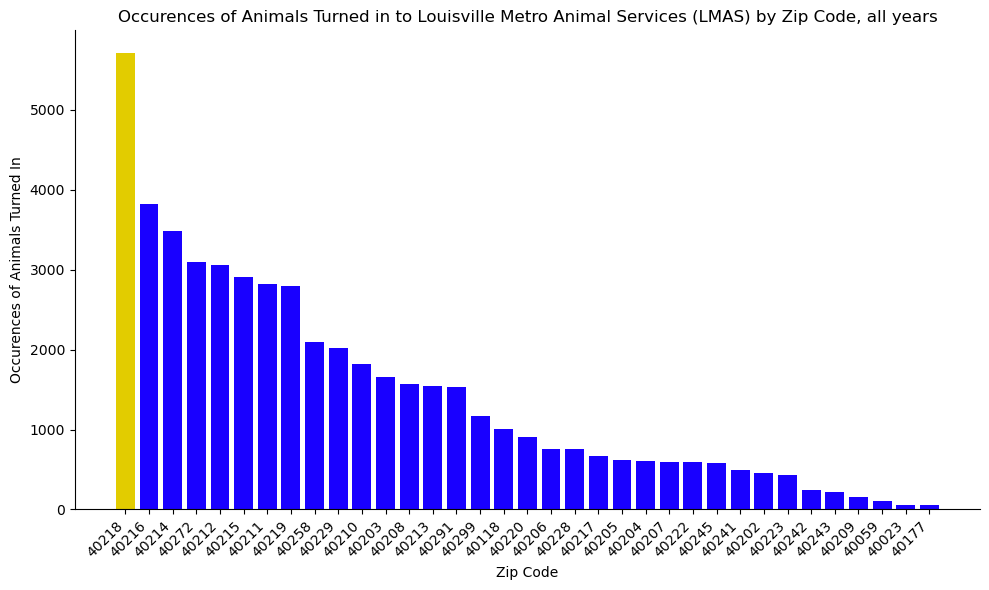

In [291]:
question1()

40218 experiences the most strays, but it is important to note that LMAS's Animal House Adoption Center is located in this zip code. In my EDA of the LMAS Intake data, I found that just because an animal is turned in over the counter (or OTC), that does not mean the zip code will be recorded as 40218. The second highest zip code is 40216, which despite being near 40218 in number, is actually quite some distance away in west to southwest Louisville. The third zip code is 40214, which is directly east of 40216.

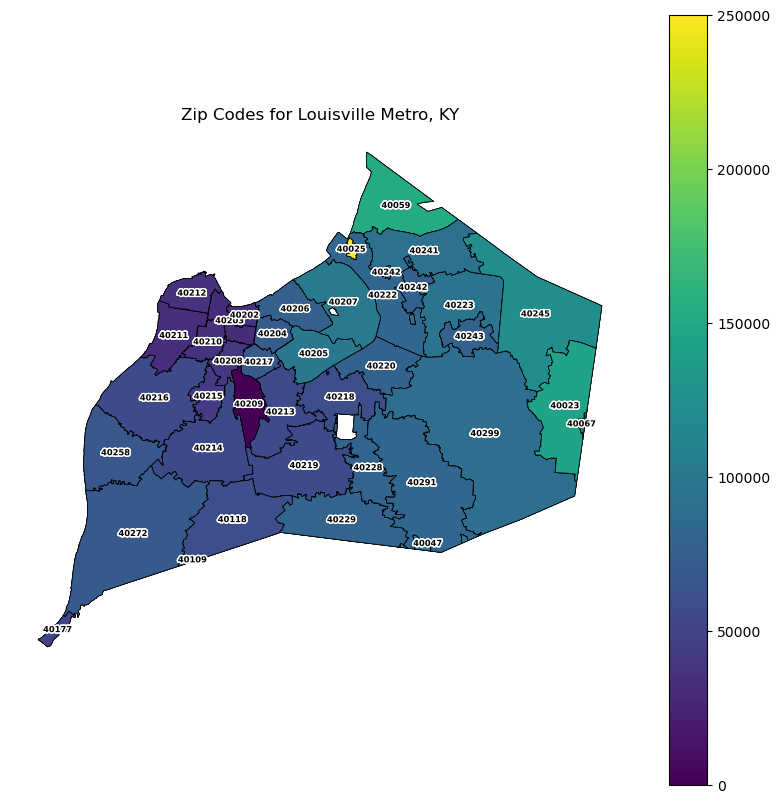

In [292]:
zip_shape_gdf = gpd.read_file('../data/shp_Jefferson_County_KY_ZIP_Codes.shp')

median_income_df['zip_code'] = median_income_df['zip_code'].astype(str).str.zfill(5)
merged_zip = zip_shape_gdf.merge(median_income_df, left_on='ZIPCODE', right_on='zip_code')

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
merged_zip.plot(edgecolor='black', column='median_income_val', ax=ax, legend=True, cmap='viridis', linewidth=0.5)
for x, y, label in zip(merged_zip.geometry.centroid.x, merged_zip.geometry.centroid.y, merged_zip.ZIPCODE):
    ax.text(x, y, label, fontsize=6, fontweight='bold', color='black', ha='center', va='center', path_effects=[pe.withStroke(linewidth=2, foreground='white')])

plt.title('Zip Codes for Louisville Metro, KY')
ax.set_axis_off()
plt.show()

#### Question 2: What are the income levels of the areas that do experience more lost, abandoned, or confiscated animals?

In [ ]:
year = '2024'

median_income_by_zip_query = pd.read_sql(f""" 
     SELECT
          COUNT(DISTINCT ind.occurence_id) AS occurence,
          ind.zip_code,
          mid.year_str,
          mid.median_income_val
     FROM intake_data AS ind
     INNER JOIN (
          SELECT
               zip_code,
               strftime('%Y', year) AS year_str,
               MAX(median_income_val) AS median_income_val
          FROM median_income_data
          GROUP BY zip_code, year_str
     ) AS mid
     ON ind.zip_code = mid.zip_code
     AND strftime('%Y', ind.intake_date) = mid.year_str
     WHERE mid.year_str = '{year}'
     GROUP BY ind.zip_code, mid.median_income_val
     ORDER BY occurence DESC;
     """, conn)

median_income_by_zip_query

,occurence,zip_code,year_str,median_income_val
0,1343,40218,2024,58811
1,844,40216,2024,56441
2,754,40214,2024,54931
3,715,40211,2024,31749
4,658,40219,2024,55720
5,623,40212,2024,35753
6,601,40272,2024,69940
7,561,40215,2024,43725
8,455,40229,2024,79936
9,441,40210,2024,35347


C:\Users\brand\AppData\Local\Temp\ipykernel_7732\3790635292.py:22: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  centroids_gdf.plot(column='occurence',


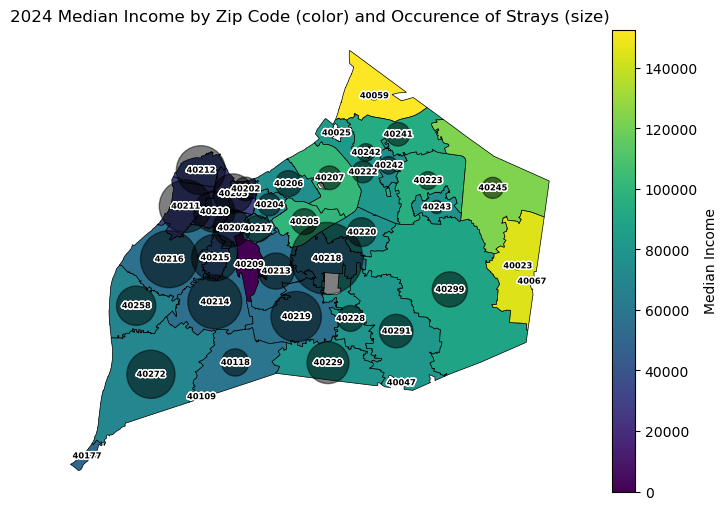

In [303]:
fig, ax = plt.subplots(1, 1, figsize=(10,6))
#google was used to get the idea and some of the code to plot bubbles on top of the map

median_income_by_zip_query['zip_code'] = median_income_by_zip_query['zip_code'].astype(str).str.zfill(5)
merged_zip_gdf = zip_shape_gdf.merge(median_income_by_zip_query, left_on='ZIPCODE', right_on='zip_code')


merged_zip_gdf.plot(column='median_income_val', 
                                cmap='viridis', 
                                legend=True, 
                                legend_kwds={'label': 'Median Income'}, 
                                edgecolor='#000000', 
                                linewidth=0.5, 
                                ax=ax)
for x, y, label in zip(merged_zip.geometry.centroid.x, merged_zip.geometry.centroid.y, merged_zip.ZIPCODE):
    ax.text(x, y, label, fontsize=6, fontweight='bold', color='black', ha='center', va='center', path_effects=[pe.withStroke(linewidth=2, foreground='white')])
    

merged_zip_gdf['centroid'] = merged_zip_gdf.geometry.centroid
centroids_gdf = merged_zip_gdf.set_geometry('centroid')

centroids_gdf.plot(column='occurence',
                   ax=ax,
                   markersize=centroids_gdf['occurence'] * 2,
                   color='#000000',
                   alpha=0.5,
                   legend=False)

ax.set_title('2024 Median Income by Zip Code (color) and Occurence of Strays (size)')
ax.axis('off')

plt.show()

In [304]:
cursor.close()
conn.close()